# Hierarchical Clustering

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Importing the dataset

In [3]:
dataset = pd.read_csv("../Data/Mall_Customers.csv")
dataset

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [28]:
X = dataset.iloc[:, 2:].values
X

array([[ 19,  15,  39],
       [ 21,  15,  81],
       [ 20,  16,   6],
       [ 23,  16,  77],
       [ 31,  17,  40],
       [ 22,  17,  76],
       [ 35,  18,   6],
       [ 23,  18,  94],
       [ 64,  19,   3],
       [ 30,  19,  72],
       [ 67,  19,  14],
       [ 35,  19,  99],
       [ 58,  20,  15],
       [ 24,  20,  77],
       [ 37,  20,  13],
       [ 22,  20,  79],
       [ 35,  21,  35],
       [ 20,  21,  66],
       [ 52,  23,  29],
       [ 35,  23,  98],
       [ 35,  24,  35],
       [ 25,  24,  73],
       [ 46,  25,   5],
       [ 31,  25,  73],
       [ 54,  28,  14],
       [ 29,  28,  82],
       [ 45,  28,  32],
       [ 35,  28,  61],
       [ 40,  29,  31],
       [ 23,  29,  87],
       [ 60,  30,   4],
       [ 21,  30,  73],
       [ 53,  33,   4],
       [ 18,  33,  92],
       [ 49,  33,  14],
       [ 21,  33,  81],
       [ 42,  34,  17],
       [ 30,  34,  73],
       [ 36,  37,  26],
       [ 20,  37,  75],
       [ 65,  38,  35],
       [ 24,  38

## Encode the categorical Column

In [12]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

ct = ColumnTransformer(transformers = [('encoder', OneHotEncoder(), [0])], remainder = 'passthrough')
X = np.array(ct.fit_transform(X))
X

array([[0.0, 1.0, 19, 15, 39],
       [0.0, 1.0, 21, 15, 81],
       [1.0, 0.0, 20, 16, 6],
       [1.0, 0.0, 23, 16, 77],
       [1.0, 0.0, 31, 17, 40],
       [1.0, 0.0, 22, 17, 76],
       [1.0, 0.0, 35, 18, 6],
       [1.0, 0.0, 23, 18, 94],
       [0.0, 1.0, 64, 19, 3],
       [1.0, 0.0, 30, 19, 72],
       [0.0, 1.0, 67, 19, 14],
       [1.0, 0.0, 35, 19, 99],
       [1.0, 0.0, 58, 20, 15],
       [1.0, 0.0, 24, 20, 77],
       [0.0, 1.0, 37, 20, 13],
       [0.0, 1.0, 22, 20, 79],
       [1.0, 0.0, 35, 21, 35],
       [0.0, 1.0, 20, 21, 66],
       [0.0, 1.0, 52, 23, 29],
       [1.0, 0.0, 35, 23, 98],
       [0.0, 1.0, 35, 24, 35],
       [0.0, 1.0, 25, 24, 73],
       [1.0, 0.0, 46, 25, 5],
       [0.0, 1.0, 31, 25, 73],
       [1.0, 0.0, 54, 28, 14],
       [0.0, 1.0, 29, 28, 82],
       [1.0, 0.0, 45, 28, 32],
       [0.0, 1.0, 35, 28, 61],
       [1.0, 0.0, 40, 29, 31],
       [1.0, 0.0, 23, 29, 87],
       [0.0, 1.0, 60, 30, 4],
       [1.0, 0.0, 21, 30, 73],
       [0.0, 

## Feature Scaling

In [ ]:
# from sklearn.preprocessing import StandardScaler

# sc = StandardScaler()
# X[:, 2:] = sc.fit_transform(X[:, 2:])
# X, 

# for this dataset, feature scaling makes it even worse

(array([[0.0, 1.0, -1.4245687900521389, -1.7389991930659479,
         -0.43480147996914836],
        [0.0, 1.0, -1.2810354107017976, -1.7389991930659479,
         1.1957040699151575],
        [1.0, 0.0, -1.3528021003769684, -1.7008297638941756,
         -1.7159129834496745],
        [1.0, 0.0, -1.137502031351456, -1.7008297638941756,
         1.0404178270690332],
        [1.0, 0.0, -0.5633685139500902, -1.6626603347224032,
         -0.3959799192576173],
        [1.0, 0.0, -1.2092687210266269, -1.6626603347224032,
         1.001596266357502],
        [1.0, 0.0, -0.27630175524940737, -1.624490905550631,
         -1.7159129834496745],
        [1.0, 0.0, -1.137502031351456, -1.624490905550631,
         1.7003843591650618],
        [0.0, 1.0, 1.8049322453305436, -1.5863214763788585,
         -1.8323776655842676],
        [1.0, 0.0, -0.635135203625261, -1.5863214763788585,
         0.8463100235113777],
        [0.0, 1.0, 2.020232314356056, -1.5863214763788585,
         -1.4053404977574258],


## Using the dendrogram to find the optimal number of clusters

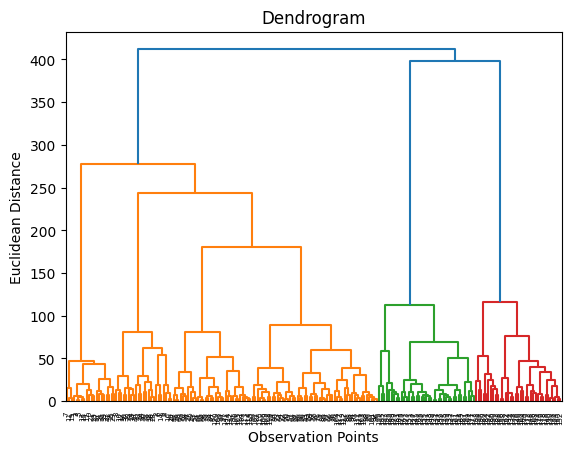

In [29]:
import scipy.cluster.hierarchy as sch

dendrogram = sch.dendrogram(sch.linkage(X, method = 'ward'))
plt.title("Dendrogram")
plt.xlabel("Observation Points")
plt.ylabel("Euclidean Distance")
plt.show()

## Training Hierarchical Clustering Model

In [30]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

bestScore = -1
bestModel = None

for linkage in ['ward', 'complete', 'average', 'single']:

    if linkage == 'ward':
        model = AgglomerativeClustering(
            n_clusters=5,
            linkage=linkage,
        )
    else:
        model = AgglomerativeClustering(
            n_clusters=5,
            linkage=linkage,
            metric='manhattan'
        )

    labels = model.fit_predict(X)

    score = silhouette_score(X, labels)

    print(linkage, score)

    if score > bestScore:
        bestScore = score
        bestModel = model

y_pred = bestModel.fit_predict(X)

ward 0.4401889024290193
complete 0.4216923808463316
average 0.4410250497890798
single 0.22586657780748104


In [ ]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X, y_pred)
print(score)

0.4410250497890798


## Excluding `age` feature from the training data

In [33]:
X = dataset.iloc[:, 3:].values
X

array([[ 15,  39],
       [ 15,  81],
       [ 16,   6],
       [ 16,  77],
       [ 17,  40],
       [ 17,  76],
       [ 18,   6],
       [ 18,  94],
       [ 19,   3],
       [ 19,  72],
       [ 19,  14],
       [ 19,  99],
       [ 20,  15],
       [ 20,  77],
       [ 20,  13],
       [ 20,  79],
       [ 21,  35],
       [ 21,  66],
       [ 23,  29],
       [ 23,  98],
       [ 24,  35],
       [ 24,  73],
       [ 25,   5],
       [ 25,  73],
       [ 28,  14],
       [ 28,  82],
       [ 28,  32],
       [ 28,  61],
       [ 29,  31],
       [ 29,  87],
       [ 30,   4],
       [ 30,  73],
       [ 33,   4],
       [ 33,  92],
       [ 33,  14],
       [ 33,  81],
       [ 34,  17],
       [ 34,  73],
       [ 37,  26],
       [ 37,  75],
       [ 38,  35],
       [ 38,  92],
       [ 39,  36],
       [ 39,  61],
       [ 39,  28],
       [ 39,  65],
       [ 40,  55],
       [ 40,  47],
       [ 40,  42],
       [ 40,  42],
       [ 42,  52],
       [ 42,  60],
       [ 43,

## Training the Hierarchical Clustering model on new dataset

In [34]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

bestScore = -1
bestModel = None

for linkage in ['ward', 'complete', 'average', 'single']:

    if linkage == 'ward':
        model = AgglomerativeClustering(
            n_clusters=5,
            linkage=linkage,
        )
    else:
        model = AgglomerativeClustering(
            n_clusters=5,
            linkage=linkage,
            metric='manhattan'
        )

    labels = model.fit_predict(X)

    score = silhouette_score(X, labels)

    print(linkage, score)

    if score > bestScore:
        bestScore = score
        bestModel = model

y_pred = bestModel.fit_predict(X)

ward 0.5529945955148897
complete 0.4431754483498432
average 0.5503616251703486
single 0.28037071696498683


## Evaluate the model

In [35]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X, y_pred)
print(score)

0.5529945955148897


## Why Did Adding More Features Reduce the Silhouette Score?

It is natural to think that adding more features (such as **Age** and **Gender**) should improve clustering because customer shopping behavior may depend on these factors.

However, in Machine Learning, **more features do not always lead to better results**.

### Example

Consider the following customers:

| Age | Annual Income | Spending Score |
| --: | ------------: | -------------: |
|  20 |           90k |             90 |
|  21 |           91k |             91 |
|  60 |           89k |             90 |
|  61 |           90k |             91 |

Notice that all four customers have almost the same **Annual Income** and **Spending Score**. Therefore, their shopping behavior is very similar.

If clustering is performed using only:

* Annual Income
* Spending Score

the algorithm correctly places these customers in the same cluster.

However, when **Age** is added, the algorithm also considers the large age difference (20 vs. 60). As a result, it may separate customers who actually have very similar shopping behavior.

This reduces the compactness of clusters and lowers the Silhouette Score.

---

### Does This Mean Age Is Useless?

No.

Age can still be an important feature for many Machine Learning tasks such as:

* Customer purchase prediction (Classification)
* Spending prediction (Regression)
* Marketing analysis

However, for **this particular clustering problem**, Age did not help create better-separated clusters.

---

### Conclusion

Feature selection should always be based on experimental results rather than assumptions.

For the Mall Customers dataset:

| Features Used                                 | Silhouette Score |
| --------------------------------------------- | ---------------: |
| Annual Income + Spending Score                |         **0.55** |
| Age + Annual Income + Spending Score          |         **0.44** |
| Gender + Age + Annual Income + Spending Score |         **0.44** |

Since using only **Annual Income** and **Spending Score** produced the highest Silhouette Score, these two features were selected for the final clustering model.

#### Key Takeaway

> More features do **not** always produce a better model. A feature should only be included if it improves the quality of the clustering.
